# Generate t-SNE visualizations for speaker embeddings

In [5]:
def refactor_features(features):
    keys = features.keys()
    refactored = {}
    for key in keys:
        # split the key by / and take the first part
        new_key = key.split('/')[0]
        # if the new_key is not in refactored, create an empty list
        if new_key not in refactored:
            refactored[new_key] = []
        # append the feature to the list
        refactored[new_key].append(features[key])
    return refactored

In [6]:
v2_softmaxproto_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/ResNetSE34Lv2_softmaxproto/result/features.pkl"
v2_softmax_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/ResNetSE34Lv2_softmax/result/features.pkl"
v2_AAMSoftmax_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/ResNetSE34Lv2_AAMSoftmax/result/features.pkl"
v1_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/v1_1/result/features.pkl"
Res2Next6s8g = '/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/Res2NeXt6s8g_training_balanced/result/features.pkl'

res_6g_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/res_6g/result/features.pkl"
res_8s_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/res_8s/result/features.pkl"
res_bott_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/res_bott/result/features.pkl"
res_6s8g_path = "/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/eval/Res2NeXt6s8g/result/features.pkl"

emb_512 = {
    "ResNetSE34V2": v2_softmaxproto_path,
    # "ResNetSE34V2 SM": v2_softmax_path,
    # "ResNetSE34V2 AAM-SM": v2_AAMSoftmax_path,
    "ResNetSE34L": v1_path,
    "Res2NeXt-6s8g(512)": Res2Next6s8g,
}
emb_256 = {
    "ResNeXt-6g": res_6g_path,
    "Res2Net-8s": res_8s_path,
    "ResNet-baseline": res_bott_path,
    "Res2NeXt-6s8g": res_6s8g_path,
}
# emb_256_model_names = ["res_6g","res_8s","res_bott","res_6s8g"]

In [5]:
emb_256_model_names = ["res_6g","res_8s","res_bott","res_6s8g"]

In [7]:
# open the v2_softmaxproto_path and load the dictionary with pickle
for key in emb_512:
    with open(emb_512[key], 'rb') as f:
        features = pickle.load(f)
        emb_512[key] = refactor_features(features)


for key in emb_256:
    with open(emb_256[key], 'rb') as f:
        features = pickle.load(f)
        emb_256[key] = refactor_features(features)

In [3]:
l = {}
for key in emb_512["v2_softmaxproto"]:
    l[key] = len(emb_512["v2_softmaxproto"][key])

# sort the keys by the length of the list
sorted_keys = sorted(l, key=l.get, reverse=True)
for k in sorted_keys:
    print(f"{k}: {l[k]}")

KeyError: 'v2_softmaxproto'

In [19]:

y = []
data_subset = []
# for key in emb_512["v2_softmaxproto"]:
# for key in ['id10292','id10296','id10301']:
# for model in ["v2_softmaxproto","v1"]:
for model in list(emb_256.keys()):
    for idx, key in enumerate(['id10293','id10302'] ): # emb_256[model].keys() # ['id10292','id10300'] #,'id10273'
        for i in range(len(emb_256[model][key])):
            data_subset.append(emb_256[model][key][i][0].numpy().tolist())
            y.append(model + "_" + str(idx))

data_subset = np.array(data_subset)
print(data_subset.shape)
# print(y)

(1436, 256)


In [8]:

y = []
data_subset = []
# for key in emb_512["v2_softmaxproto"]:
# for key in ['id10292','id10296','id10301']:
# for model in ["v2_softmaxproto","v1"]:
for model in list(emb_512.keys()):
    for idx, key in enumerate(['id10293','id10302'] ): # emb_256[model].keys() # ['id10292','id10300'] #,'id10273'
        for i in range(len(emb_512[model][key])):
            data_subset.append(emb_512[model][key][i][0].numpy().tolist())
            y.append(model + "_" + str(idx))

data_subset = np.array(data_subset)
print(data_subset.shape)
# print(y)

(1077, 512)


In [15]:
time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=20, n_iter=1000)
tsne_result = tsne.fit_transform(data_subset)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

/home/lenny/anaconda3/envs/lola2/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1077 samples in 0.000s...
[t-SNE] Computed neighbors for 1077 samples in 0.017s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1077
[t-SNE] Computed conditional probabilities for sample 1077 / 1077
[t-SNE] Mean sigma: 1.968206
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.735016
[t-SNE] KL divergence after 1000 iterations: 0.876467
t-SNE done! Time elapsed: 0.8160173892974854 seconds


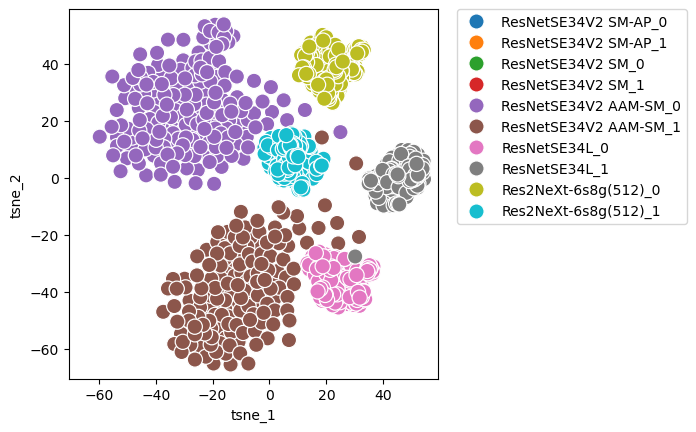

In [10]:
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': y})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

/tmp/ipykernel_1604913/2597483151.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model


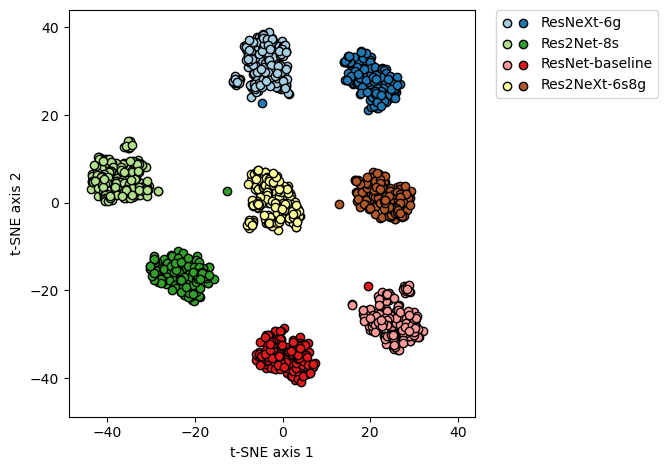

In [21]:
# tsne_result_df = pd.DataFrame({'t-SNE axis 1': tsne_result[:,0], 't-SNE axis 2': tsne_result[:,1], 'label': y})
from matplotlib.legend_handler import HandlerTuple
# models = [[[],[]] for _ in range(len(emb_256))]  # list of lists to hold x and y coordinates for each model
models_result = {}
cmap = plt.get_cmap('Paired')
cmap_list = [cmap(i) for i in range(6)] + [cmap(i) for i in range(10,12)]  # create a list of colors from the colormap


# cmap = plt.get_cmap('tab20')
# cmap_list = [cmap(i) for i in range(8)] 

for key in emb_256:
    models_result[key] = [[[],[]],[[],[]]]
for idx,l in enumerate(y):
    ls = l.split('_')
    if int(ls[-1]) > 1: continue
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][0].append(tsne_result[idx,0])
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][1].append(tsne_result[idx,1])


fig, ax = plt.subplots(1)
c = 0
plots = []
for model in models_result.keys():
    for point in range(len(models_result[model])):
        x1, x2 = models_result[model][point]
        plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model
        c += 1

lim = (tsne_result.min()-5, tsne_result.max()+5)
l = ax.legend([(plots[i],plots[i+1]) for i in range(0,len(plots),2)], list(emb_256.keys()),
               handler_map={tuple: HandlerTuple(ndivide=None)},bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel('t-SNE axis 1')
ax.set_ylabel('t-SNE axis 2')
plt.tight_layout()

plt.savefig('tSNE/tsne_256.pdf', bbox_inches='tight')
# plt.show()
# ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

/tmp/ipykernel_1612008/3473574780.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model


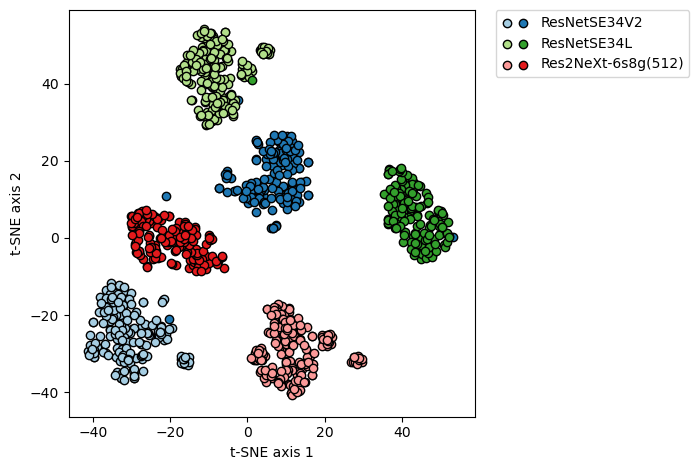

In [16]:
# tsne_result_df = pd.DataFrame({'t-SNE axis 1': tsne_result[:,0], 't-SNE axis 2': tsne_result[:,1], 'label': y})
from matplotlib.legend_handler import HandlerTuple
# models = [[[],[]] for _ in range(len(emb_256))]  # list of lists to hold x and y coordinates for each model
models_result = {}
cmap = plt.get_cmap('Paired')
cmap_list = [cmap(i) for i in range(len(list(emb_512.keys()))*2)] + [cmap(i) for i in range(10,12)]  # create a list of colors from the colormap


# cmap = plt.get_cmap('tab20')
# cmap_list = [cmap(i) for i in range(8)] 

for key in emb_512:
    models_result[key] = [[[],[]],[[],[]]]
for idx,l in enumerate(y):
    ls = l.split('_')
    if int(ls[-1]) > 1: continue
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][0].append(tsne_result[idx,0])
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][1].append(tsne_result[idx,1])


fig, ax = plt.subplots(1)
c = 0
plots = []
for model in models_result.keys():
    for point in range(len(models_result[model])):
        x1, x2 = models_result[model][point]
        plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model
        c += 1

lim = (tsne_result.min()-5, tsne_result.max()+5)
l = ax.legend([(plots[i],plots[i+1]) for i in range(0,len(plots),2)], list(emb_512.keys()),
               handler_map={tuple: HandlerTuple(ndivide=None)},bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel('t-SNE axis 1')
ax.set_ylabel('t-SNE axis 2')
plt.tight_layout()

plt.savefig('tSNE/tsne_512.pdf', bbox_inches='tight')
# plt.show()
# ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

# CUT

/tmp/ipykernel_431629/2960242210.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model


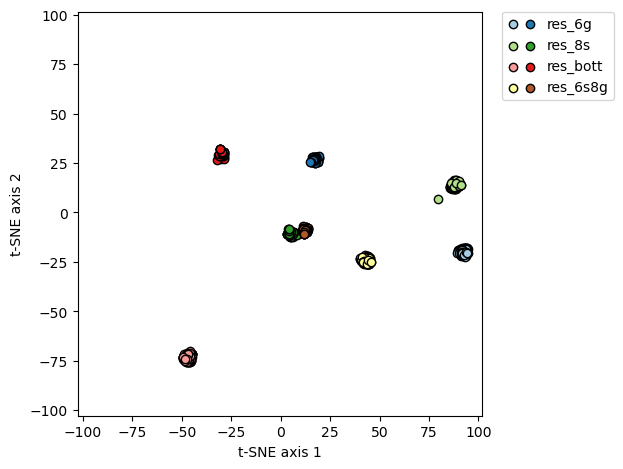

In [113]:
# tsne_result_df = pd.DataFrame({'t-SNE axis 1': tsne_result[:,0], 't-SNE axis 2': tsne_result[:,1], 'label': y})
from matplotlib.legend_handler import HandlerTuple
# models = [[[],[]] for _ in range(len(emb_256))]  # list of lists to hold x and y coordinates for each model
# models_result = {}
cmap = plt.get_cmap('Paired')
cmap_list = [cmap(i) for i in range(6)] + [cmap(i) for i in range(10,12)]  # create a list of colors from the colormap


# cmap = plt.get_cmap('tab20')
# cmap_list = [cmap(i) for i in range(8)] 

for key in emb_256:
    models_result[key] = [[[],[]],[[],[]]]
for idx,l in enumerate(y):
    ls = l.split('_')
    if int(ls[-1]) > 1: continue
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][0].append(tsne_result[idx,0])
    models_result["_".join(l.split('_')[:-1])][int(ls[-1])][1].append(tsne_result[idx,1])


fig, ax = plt.subplots(1)
c = 0
plots = []
for model in models_result.keys():
    for point in range(len(models_result[model])):
        x1, x2 = models_result[model][point]
        plots.append(ax.scatter(x1, x2, c=cmap_list[c],edgecolors='black'))#,s=120 label=model
        c += 1

lim = (tsne_result.min()-5, tsne_result.max()+5)
l = ax.legend([(plots[i],plots[i+1]) for i in range(0,len(plots),2)], emb_256_model_names,
               handler_map={tuple: HandlerTuple(ndivide=None)},bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel('t-SNE axis 1')
ax.set_ylabel('t-SNE axis 2')
plt.tight_layout()
plt.show()
# ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

In [ ]:
tsne_result_df = pd.DataFrame({'t-SNE axis 1': tsne_result[:,0], 't-SNE axis 2': tsne_result[:,1], 'label': y})
fig, ax = plt.subplots(1)
plt.scatter(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

In [46]:
models = [[[],[]] for _ in range(len(emb_256))]

# Test all embeddings

(359, 256)
359
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 359 samples in 0.000s...
[t-SNE] Computed neighbors for 359 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 359 / 359
[t-SNE] Mean sigma: 0.306588
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.590591


/home/lenny/anaconda3/envs/lola2/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 1000 iterations: 0.934432
t-SNE done! Time elapsed: 0.31923532485961914 seconds


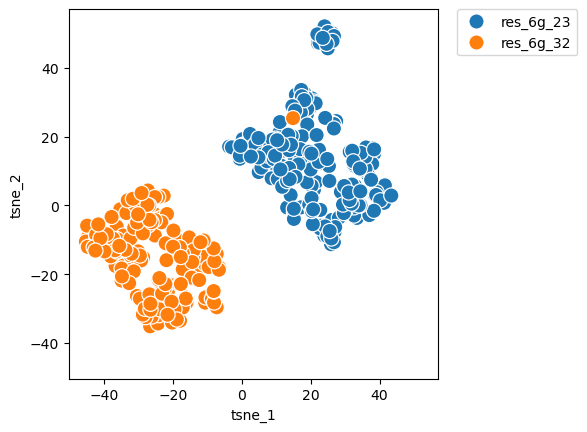

In [ ]:

y = []
data_subset = []
# for key in emb_512["v2_softmaxproto"]:
# for key in ['id10292','id10296','id10301']:
# for model in ["v2_softmaxproto","v1"]:
# for model in ["res_6g"]: #["res_6g","res_8s","res_bott","res_6s8g"]
for model in ["res_6g"]: #["res_6g","res_8s","res_bott","res_6s8g"]
    for idx, key in enumerate(  emb_256[model].keys()): # emb_256[model].keys() # ['id10292','id10300'] #,'id10273'
        if idx < 4 or idx > 34: continue
        if idx > 7 and idx < 20: continue
        if idx < 21: continue
        if idx != 23 and idx != 32: continue
        for i in range(len(emb_256[model][key])):
            data_subset.append(emb_256[model][key][i][0].numpy().tolist())
            y.append(model + "_" + str(idx))

data_subset = np.array(data_subset)
print(data_subset.shape)
print(len(y))

time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=10, n_iter=1000)
tsne_result = tsne.fit_transform(data_subset)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': y})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=1000)
tsne_result = tsne.fit_transform(data_subset)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

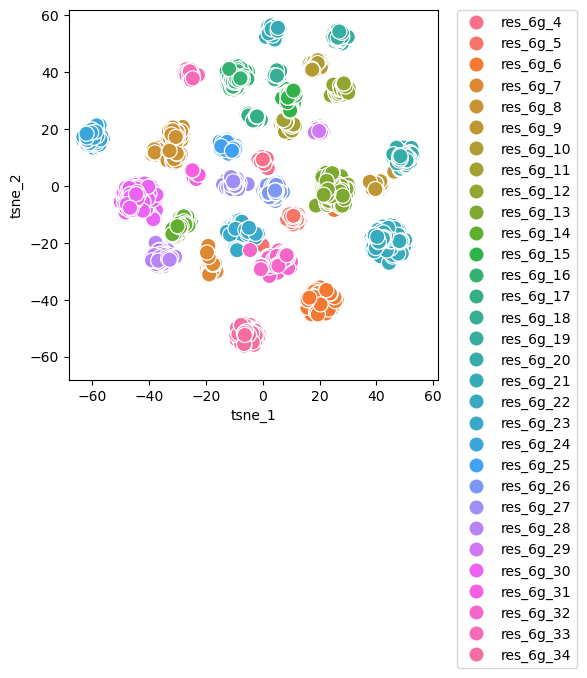